# Retea Neuronala MLP – Rezistenta Betonului

Scopul: sa invatam un model sa prezica **rezistenta betonului (MPa)** in functie de ingredientele amestecului.

Vom testa **8 configuratii** diferite, variind:
- Numarul de **straturi ascunse**: 1 sau 2
- Numarul de **neuroni pe strat**: egal cu stratul anterior sau jumatate
- **Learning rate** (cat de repede invata reteaua): 0.1 sau 0.01

**Metrica folosita: MAE** (Mean Absolute Error) = eroarea medie in MPa. Cu cat mai mic, cu atat mai bine.

In [1]:
# Importam librariile necesare
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error
from itertools import product

print('Librarii incarcate!')

Librarii incarcate!


## 1. Incarcarea datelor

In [7]:
df = pd.read_csv('Concrete_Data.csv')

# Redenumim coloanele ca sa fie mai usor de citit
df.columns = [
    'Ciment', 'Zgura', 'Cenusa_Zbor',
    'Apa', 'Superplastifiant', 'Agreg_Grosier',
    'Agreg_Fin', 'Varsta_Zile', 'Rezistenta_MPa'
]

print(f'Dataset: {df.shape[0]} exemple, {df.shape[1]-1} variabile de intrare')
print(f'Tinta de prezis: Rezistenta_MPa')
display(df.head())

print(f'\n Statistici descriptive:')
display(df.describe().round(2))

print(f'\n Valori lipsă: {df.isnull().sum().sum()}')

Dataset: 1030 exemple, 8 variabile de intrare
Tinta de prezis: Rezistenta_MPa


,Ciment,Zgura,Cenusa_Zbor,Apa,Superplastifiant,Agreg_Grosier,Agreg_Fin,Varsta_Zile,Rezistenta_MPa
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30



 Statistici descriptive:


,Ciment,Zgura,Cenusa_Zbor,Apa,Superplastifiant,Agreg_Grosier,Agreg_Fin,Varsta_Zile,Rezistenta_MPa
count,1030.00,1030.00,1030.00,1030.00,1030.00,1030.00,1030.00,1030.00,1030.00
mean,281.17,73.90,54.19,181.57,6.20,972.92,773.58,45.66,35.82
std,104.51,86.28,64.00,21.35,5.97,77.75,80.18,63.17,16.71
min,102.00,0.00,0.00,121.80,0.00,801.00,594.00,1.00,2.33
25%,192.38,0.00,0.00,164.90,0.00,932.00,730.95,7.00,23.71
50%,272.90,22.00,0.00,185.00,6.40,968.00,779.50,28.00,34.44
75%,350.00,142.95,118.30,192.00,10.20,1029.40,824.00,56.00,46.14
max,540.00,359.40,200.10,247.00,32.20,1145.00,992.60,365.00,82.60



 Valori lipsă: 0


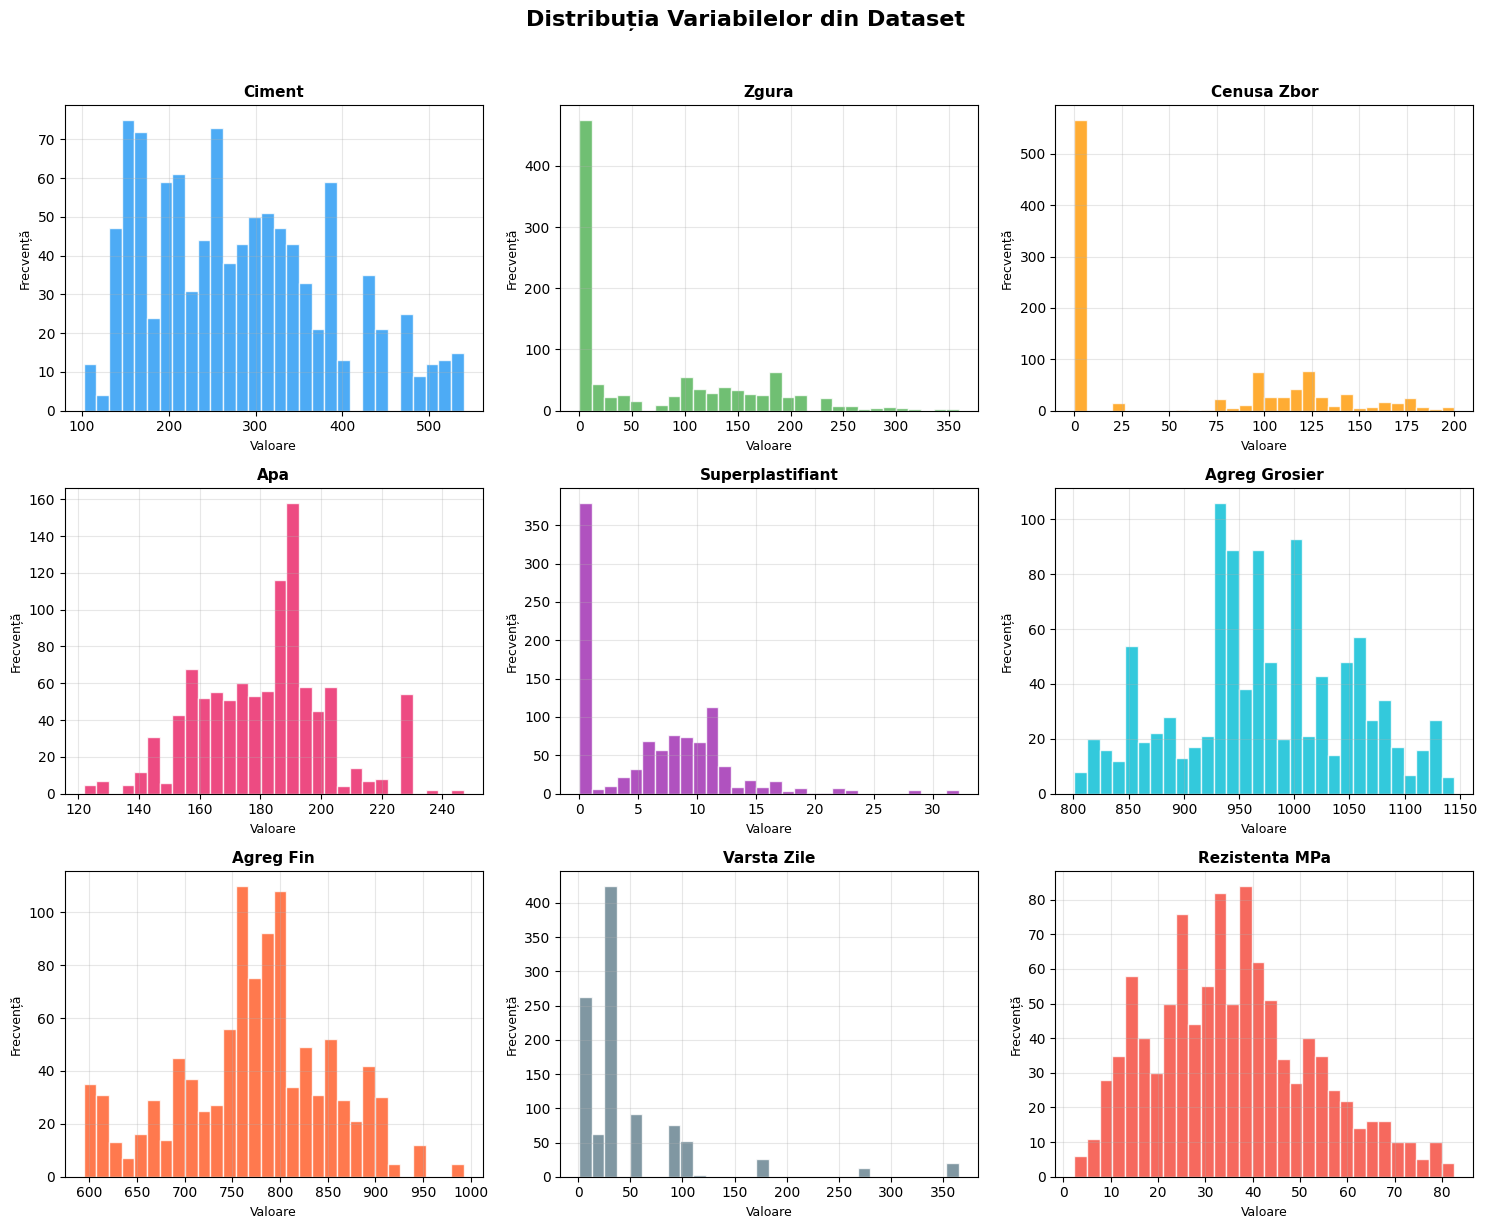

✅ Grafic distribuții salvat!


In [8]:
# ============================================================
# VIZUALIZARE EXPLORATORIE
# ============================================================
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
fig.suptitle('Distribuția Variabilelor din Dataset', fontsize=16, fontweight='bold', y=1.02)

colors = ['#2196F3', '#4CAF50', '#FF9800', '#E91E63', 
          '#9C27B0', '#00BCD4', '#FF5722', '#607D8B', '#F44336']

for idx, (col, ax, color) in enumerate(zip(df.columns, axes.flatten(), colors)):
    ax.hist(df[col], bins=30, color=color, alpha=0.8, edgecolor='white')
    ax.set_title(col.replace('_', ' '), fontsize=11, fontweight='bold')
    ax.set_xlabel('Valoare', fontsize=9)
    ax.set_ylabel('Frecvență', fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('distributii.png', dpi=120, bbox_inches='tight')
plt.show()
print('✅ Grafic distribuții salvat!')

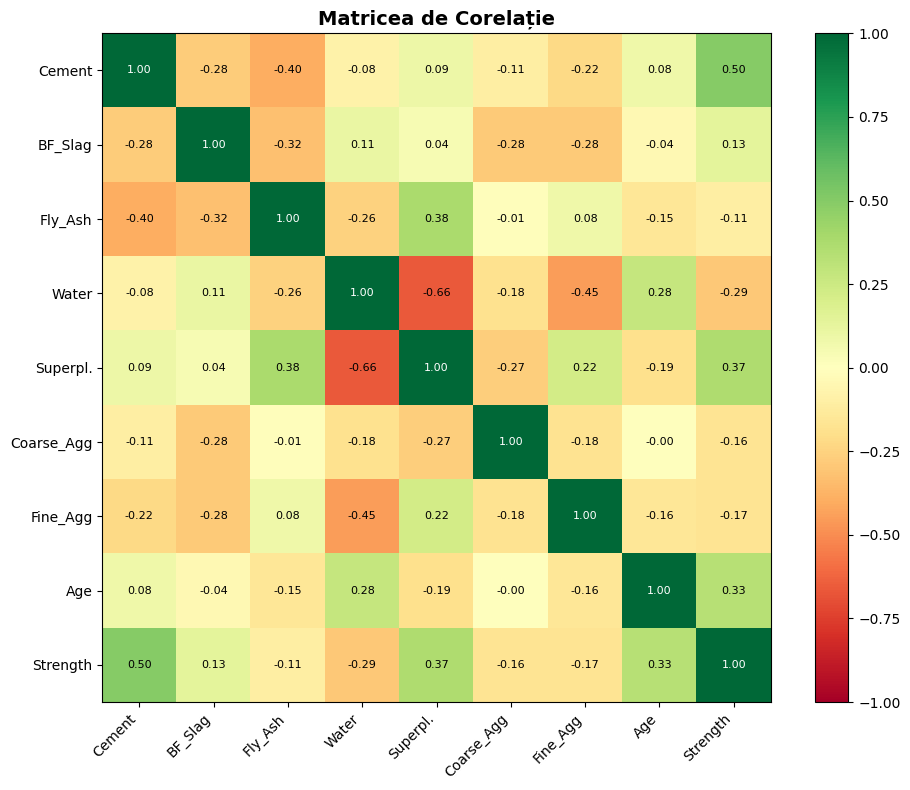

In [9]:
# Matricea de corelatie
fig, ax = plt.subplots(figsize=(10, 8))
corr_matrix = df.corr()
im = ax.imshow(corr_matrix, cmap='RdYlGn', vmin=-1, vmax=1)
plt.colorbar(im, ax=ax)

cols_short = ['Cement', 'BF_Slag', 'Fly_Ash', 'Water', 'Superpl.', 
              'Coarse_Agg', 'Fine_Agg', 'Age', 'Strength']
ax.set_xticks(range(len(cols_short)))
ax.set_yticks(range(len(cols_short)))
ax.set_xticklabels(cols_short, rotation=45, ha='right')
ax.set_yticklabels(cols_short)

for i in range(len(corr_matrix)):
    for j in range(len(corr_matrix)):
        ax.text(j, i, f'{corr_matrix.iloc[i, j]:.2f}', 
                ha='center', va='center', fontsize=8,
                color='black' if abs(corr_matrix.iloc[i, j]) < 0.7 else 'white')

ax.set_title('Matricea de Corelație', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('corelatie.png', dpi=120, bbox_inches='tight')
plt.show()

## 2. Pregatirea datelor

- Impartim datele: **80% pentru antrenament**, 20% pentru testare
- **Normalizam** valorile (StandardScaler) – reteaua neurala invata mai bine cand toate valorile sunt pe aceeasi scara

In [10]:
X = df.drop('Rezistenta_MPa', axis=1)
y = df['Rezistenta_MPa']

n_input = X.shape[1]  # 8 variabile de intrare

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train_sc = scaler_X.fit_transform(X_train)
X_test_sc  = scaler_X.transform(X_test)
y_train_sc = scaler_y.fit_transform(y_train.values.reshape(-1, 1)).ravel()

print(f'Date antrenament : {X_train_sc.shape[0]} exemple')
print(f'Date test        : {X_test_sc.shape[0]} exemple')
print('Normalizare aplicata!')

Date antrenament : 824 exemple
Date test        : 206 exemple
Normalizare aplicata!


## 3. Definirea configuratiilor

Pornim cu **8 neuroni** pe primul strat (egal cu numarul de variabile de intrare).

| Schema neuroni | 1 strat ascuns | 2 straturi ascunse |
|---|---|---|
| **Egal** | (8,) | (8, 8) |
| **Jumatate** | (8,) | (8, 4) |

In [11]:
def construieste_straturi(n_straturi, schema, primul_strat):
    """Returneaza un tuple cu numarul de neuroni pe fiecare strat ascuns."""
    straturi = [primul_strat]
    for _ in range(1, n_straturi):
        if schema == 'egal':
            straturi.append(straturi[-1])
        else:  # jumatate
            straturi.append(max(1, straturi[-1] // 2))
    return tuple(straturi)

# Toate combinatiile posibile
combinatii = list(product([1, 2], ['egal', 'jumatate'], [0.1, 0.01]))

print(f'Total configuratii: {len(combinatii)}\n')
print(f'{"Nr":>3}  {"Straturi":>9}  {"Neuroni":>9}  {"LR":>6}  {"Arhitectura"}')
print('-' * 50)
for i, (ns, schema, lr) in enumerate(combinatii, 1):
    arch = construieste_straturi(ns, schema, n_input)
    print(f'  {i}    {ns:>7}    {schema:>9}   {lr:>5}   {arch}')

Total configuratii: 8

 Nr   Straturi    Neuroni      LR  Arhitectura
--------------------------------------------------
  1          1         egal     0.1   (8,)
  2          1         egal    0.01   (8,)
  3          1     jumatate     0.1   (8,)
  4          1     jumatate    0.01   (8,)
  5          2         egal     0.1   (8, 8)
  6          2         egal    0.01   (8, 8)
  7          2     jumatate     0.1   (8, 4)
  8          2     jumatate    0.01   (8, 4)


## 4. Antrenarea modelelor

Antrenam cate un model MLP pentru fiecare configuratie si masuram **MAE** pe datele de test.

In [12]:
rezultate = []

print(f'{"Nr":>3}  {"Arhitectura":>10}  {"LR":>6}  {"MAE (MPa)":>10}  {"Epoci"}')
print('-' * 52)

for i, (ns, schema, lr) in enumerate(combinatii, 1):
    arch = construieste_straturi(ns, schema, n_input)

    model = MLPRegressor(
        hidden_layer_sizes=arch,
        activation='relu',        # functia de activare ReLU
        solver='adam',            # optimizator Adam
        learning_rate_init=lr,
        max_iter=1000,
        early_stopping=True,      # oprire automata daca nu mai progreseaza
        n_iter_no_change=20,
        random_state=42
    )

    model.fit(X_train_sc, y_train_sc)

    # Predictii – le readucem la scara originala (MPa)
    y_pred_sc = model.predict(X_test_sc)
    y_pred = scaler_y.inverse_transform(y_pred_sc.reshape(-1, 1)).ravel()

    mae = mean_absolute_error(y_test, y_pred)

    rezultate.append({
        'Nr': i,
        'N_Straturi': ns,
        'Schema': schema,
        'Arhitectura': arch,
        'LR': lr,
        'MAE': mae,
        'Epoci': model.n_iter_,
        'Loss_Curve': model.loss_curve_
    })

    print(f'  {i}   {str(arch):>10}   {lr:>5}   {mae:>9.3f}   {model.n_iter_}')

rez = pd.DataFrame(rezultate)
print('\nAntrenare finalizata!')

 Nr  Arhitectura      LR   MAE (MPa)  Epoci
----------------------------------------------------
  1         (8,)     0.1       4.733   101
  2         (8,)    0.01       4.739   92
  3         (8,)     0.1       4.733   101
  4         (8,)    0.01       4.739   92
  5       (8, 8)     0.1       4.937   68
  6       (8, 8)    0.01       5.070   144
  7       (8, 4)     0.1       5.032   43
  8       (8, 4)    0.01       4.583   131

Antrenare finalizata!


## 5. Rezultate – Cel mai bun si cel mai slab model

In [13]:
best_idx  = rez['MAE'].idxmin()
worst_idx = rez['MAE'].idxmax()

best  = rez.iloc[best_idx]
worst = rez.iloc[worst_idx]

print('=' * 50)
print(f'CEL MAI BUN MODEL (MAE cel mai mic):')
print(f'  Configuratia #{int(best["Nr"])}')
print(f'  Arhitectura  : {best["Arhitectura"]}')
print(f'  Learning Rate: {best["LR"]}')
print(f'  MAE          : {best["MAE"]:.3f} MPa')
print()
print(f'CEL MAI SLAB MODEL (MAE cel mai mare):')
print(f'  Configuratia #{int(worst["Nr"])}')
print(f'  Arhitectura  : {worst["Arhitectura"]}')
print(f'  Learning Rate: {worst["LR"]}')
print(f'  MAE          : {worst["MAE"]:.3f} MPa')
print('=' * 50)

CEL MAI BUN MODEL (MAE cel mai mic):
  Configuratia #8
  Arhitectura  : (8, 4)
  Learning Rate: 0.01
  MAE          : 4.583 MPa

CEL MAI SLAB MODEL (MAE cel mai mare):
  Configuratia #6
  Arhitectura  : (8, 8)
  Learning Rate: 0.01
  MAE          : 5.070 MPa


## 6. Grafice

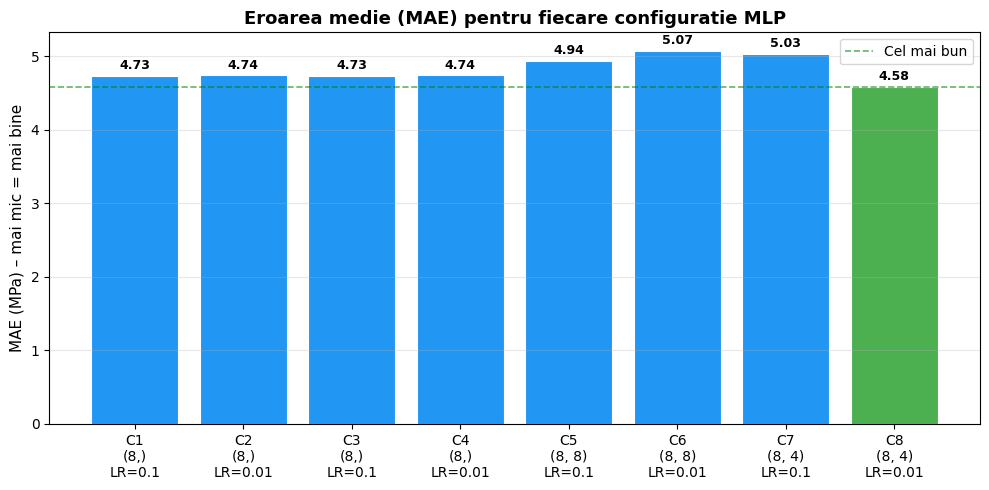

In [14]:
# --- Grafic 1: MAE pentru fiecare configuratie ---
fig, ax = plt.subplots(figsize=(10, 5))

culori = ['#4CAF50' if i == best_idx else '#2196F3' for i in range(len(rez))]
etichete = [f'C{r["Nr"]}\n{r["Arhitectura"]}\nLR={r["LR"]}' for _, r in rez.iterrows()]

bare = ax.bar(etichete, rez['MAE'], color=culori, edgecolor='white', linewidth=0.8)

for bar, val in zip(bare, rez['MAE']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f'{val:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_ylabel('MAE (MPa) – mai mic = mai bine', fontsize=11)
ax.set_title('Eroarea medie (MAE) pentru fiecare configuratie MLP', fontsize=13, fontweight='bold')
ax.axhline(rez['MAE'].min(), color='green', linestyle='--', linewidth=1.2, alpha=0.6, label='Cel mai bun')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('mae_configuratii.png', dpi=120, bbox_inches='tight')
plt.show()

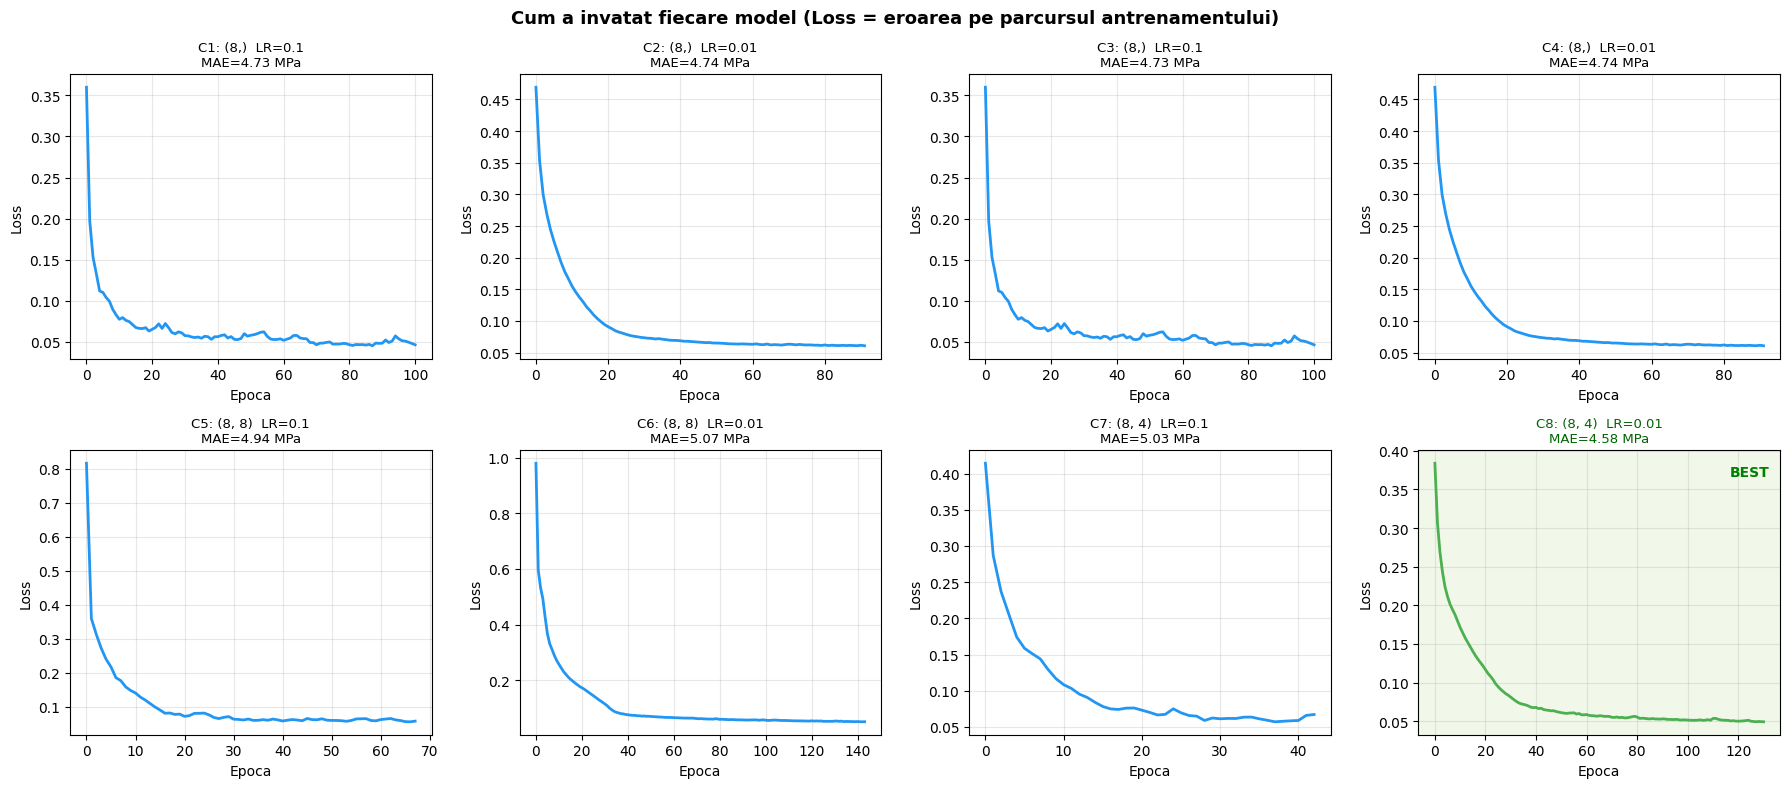

In [15]:
# --- Grafic 2: Curbele de pierdere (cum a invatat fiecare model) ---
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
fig.suptitle('Cum a invatat fiecare model (Loss = eroarea pe parcursul antrenamentului)',
             fontsize=13, fontweight='bold')

for idx, (ax, row) in enumerate(zip(axes.flatten(), rez.itertuples())):
    culoare = '#4CAF50' if idx == best_idx else '#2196F3'
    ax.plot(row.Loss_Curve, color=culoare, linewidth=2)
    titlu = f'C{row.Nr}: {row.Arhitectura}  LR={row.LR}\nMAE={row.MAE:.2f} MPa'
    ax.set_title(titlu, fontsize=9.5,
                 color='darkgreen' if idx == best_idx else 'black')
    ax.set_xlabel('Epoca')
    ax.set_ylabel('Loss')
    ax.grid(True, alpha=0.3)
    if idx == best_idx:
        ax.set_facecolor('#f1f8e9')
        ax.text(0.97, 0.95, 'BEST', transform=ax.transAxes,
                ha='right', va='top', color='green', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('loss_curves.png', dpi=120, bbox_inches='tight')
plt.show()